# Testing the limits of `sectionate` with various edge cases

Can `sectionate` handle the curvilinear geometry and complicated topology of the tripolar configuration of MOM? ***Yes.***

This notebook demonstrates its correct behavior in a number of non-trivial edge cases in which sections cross grid boundaries.

## Import packages

In [1]:
import xgcm
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.path as mpath

import cartopy.crs as ccrs
import cartopy.feature as cfeature
subplot_kws=dict(projection=ccrs.Robinson())
data_crs = ccrs.PlateCarree()

import sectionate
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.4.0rc2.dev1


## Define plotting functions

In [2]:
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad((0.8, 0.8, 0.8))

def plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.Robinson(), vlim=[0, 7500]):
    
    fig, axes = plt.subplots(1, 2, figsize=[16,6], subplot_kw={'projection':projection})
    ax = axes[0]
    ds['deptho'].plot(x='geolon', y='geolat', ax=ax, transform=data_crs, cmap=plt.get_cmap("Blues"), vmin=vlim[0], vmax=vlim[1])
    ds['deptho'].plot.contour(x='geolon', y='geolat', ax=ax, transform=data_crs, colors="k", linewidths=0.5, linestyles="solid", levels=[1.])
    ax.plot(lons_c, lats_c, 'k.-', transform=ccrs.Geodetic(), markersize=1.5, lw=0.5)
    ax.plot(section_lons, section_lats, "C3x", transform=data_crs, markersize=6., mew=3., alpha=0.85, label="Points of target section")
    ax.plot([60,60], [-75, 90], "w--", alpha=0.75, lw=1.75, transform=ccrs.Geodetic(), label="nominal ds boundary")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title("With respect to geographic coordinates")
    ax.legend(loc="upper right", fontsize=12, labelspacing=0.12)
    ax.gridlines(alpha=0.2)
    ax.set_extent([-180, 180., -80, 80], ccrs.PlateCarree())
        
    if projection==ccrs.SouthPolarStereo():
        ax.set_extent([0, 360., -90, -40], ccrs.PlateCarree())

        # Compute a circle in axes coordinates, which we can use as a boundary
        # for the map. We can pan/zoom as much as we like - the boundary will be
        # permanently circular.
        theta = np.linspace(0, 2*np.pi, 100)
        center, radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)

        ax.set_boundary(circle, transform=ax.transAxes)
        
    elif projection==ccrs.NorthPolarStereo():
        ax.set_extent([0, 360., 50, 90], ccrs.PlateCarree())

        # Compute a circle in axes coordinates, which we can use as a boundary
        # for the map. We can pan/zoom as much as we like - the boundary will be
        # permanently circular.
        theta = np.linspace(0, 2*np.pi, 100)
        center, radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)

        ax.set_boundary(circle, transform=ax.transAxes)

    ax = axes[1]
    ax = plt.subplot(1,2,2)
    pc = ax.pcolormesh(ds['deptho'].values, cmap=cmap, vmin=vlim[0], vmax=vlim[1])
    ax.contour(ds['deptho'].values, colors="k", linewidths=0.5, linestyles="solid", levels=[1.])
    ax.plot(i_c, j_c, 'k.', markersize=1.5)
    ax.set_title("With respect to model indices (i_c,j_c)");
    plt.colorbar(pc, ax=ax)
    plt.tight_layout()
    
    return fig, axes

## Load the model grid

In [3]:
from load_example_model_grid import load_MOM6_example_grid
grid = load_MOM6_example_grid()
ds = grid._ds

/opt/anaconda3/envs/sectionate-pr7/lib/python3.14/site-packages/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(


## 1.  A section that crosses the periodic `X` boundary

In [4]:
section_lons=[50, 70]
section_lats=[-55, -35]

assert section_lons[0] < ds['geolon_c'].max().values < section_lons[1]

### Desired behavior with `padding={"X":"periodic"}` (new default)

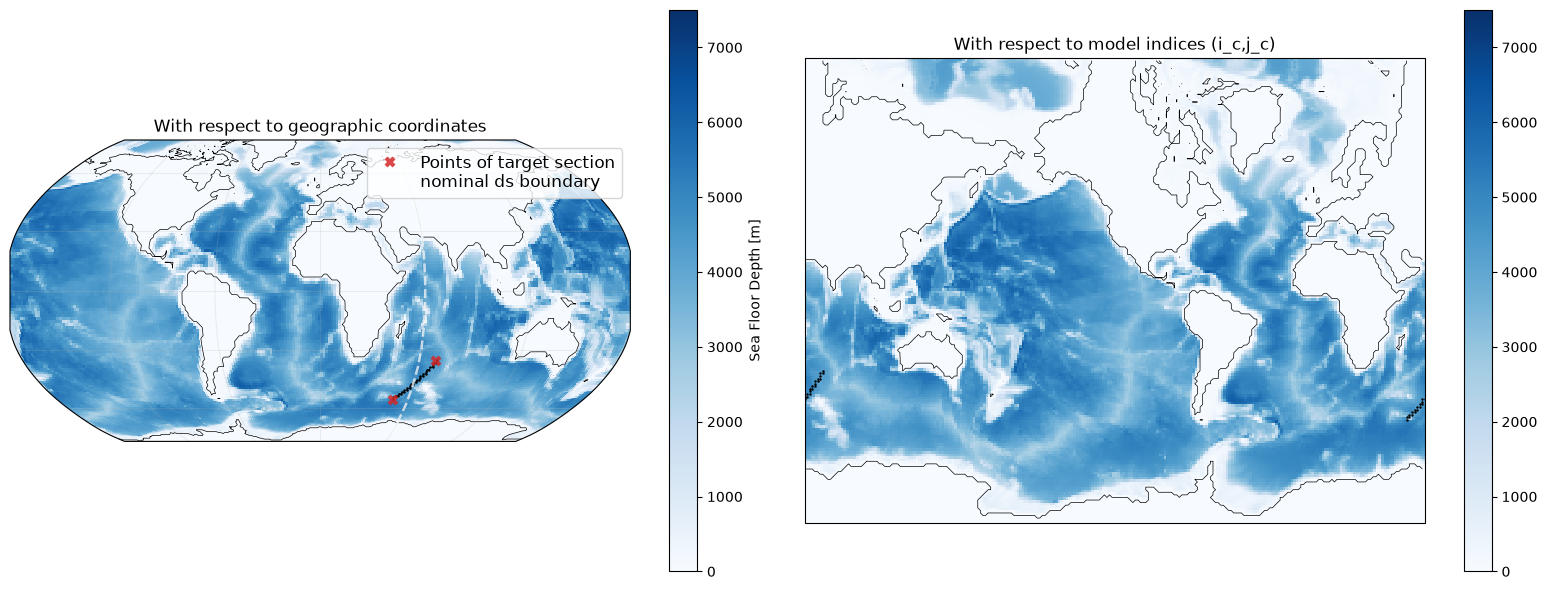

In [5]:
from sectionate.gridutils import get_geo_corners, build_neighbor_maps

# `create_section_composite` is the lower-level routine: it walks precomputed,
# topology-aware neighbor maps. `grid_section` (below) builds those maps from the
# `xgcm.Grid` for you; here we construct them explicitly and pass them in.
neighbor_maps = build_neighbor_maps(grid, get_geo_corners(grid))
i_c, j_c, lons_c, lats_c = sectionate.create_section_composite(
    grid._ds['geolon_c'],
    grid._ds['geolat_c'],
    section_lons,
    section_lats,
    neighbor_maps=neighbor_maps,
)

plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds);

The `grid_section` function builds these topology-aware neighbor maps from the `xgcm.Grid` automatically — inferring zonal periodicity, the vorticity corner staggering (`outer`/symmetric, `right`/non-symmetric, or `left`/MITgcm-ECCO), and any multi-tile `face_connections` or bipolar north fold — and calls `create_section_composite` for you. It is the recommended entry point.

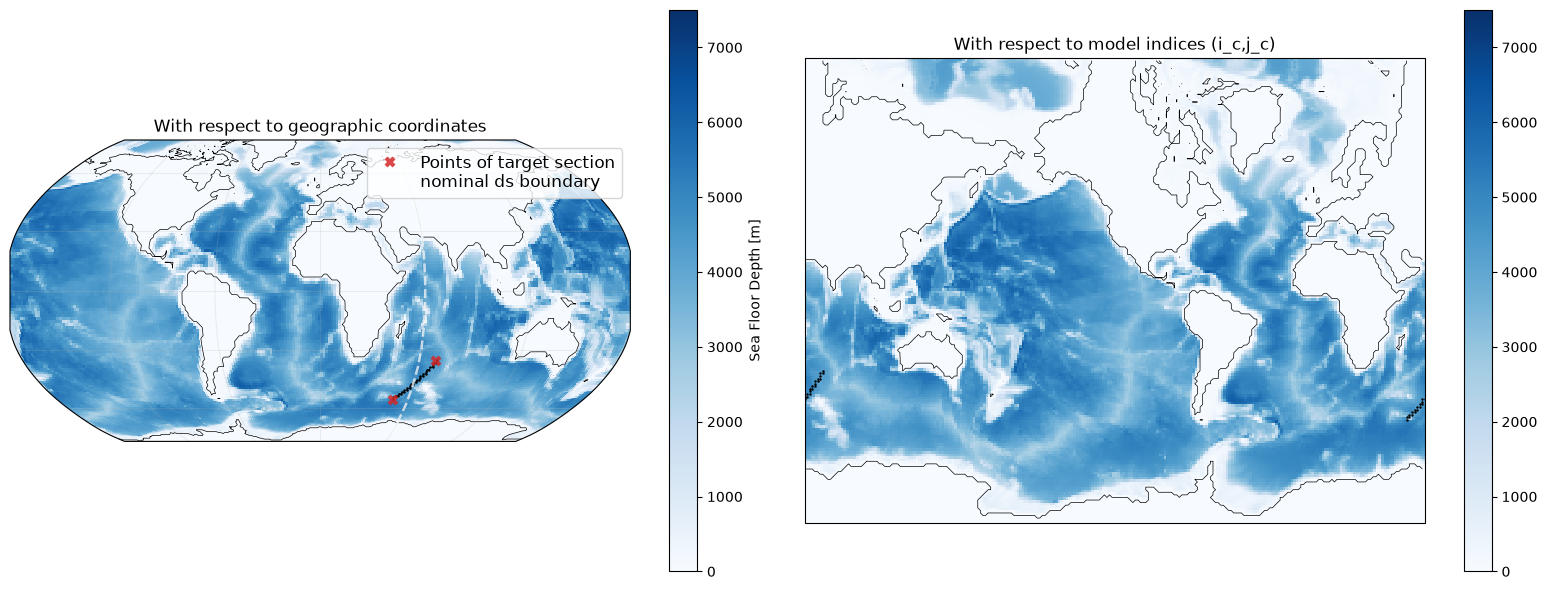

In [6]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)

plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds);

## 2.  Zonally-periodic sections

**Note:** Sectionate requires intermediate points to disambiguate zonal sections longer than 180º.

Consider the case below where we aim to make a zonally-circumpolar section that passes through Drake Passage at 60ºS.

In [7]:
lat = -57.5

### Incorrect use: no intermediate points $\rightarrow$ no section required to connect consecutive points

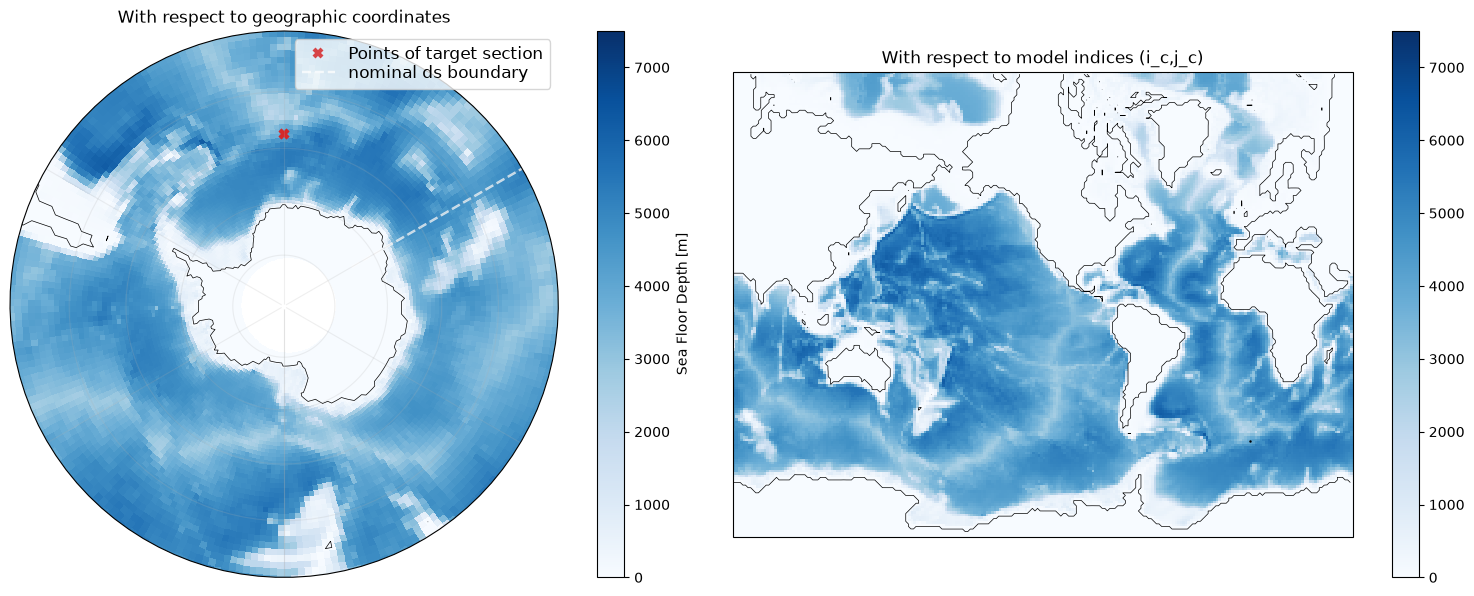

In [8]:
section_lons=[0, 360]
section_lats=[lat]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

### Incorrect use: intermediate points more than 180º apart $\rightarrow$ shortest subsections do not cirumnavigate (and just go out and back)

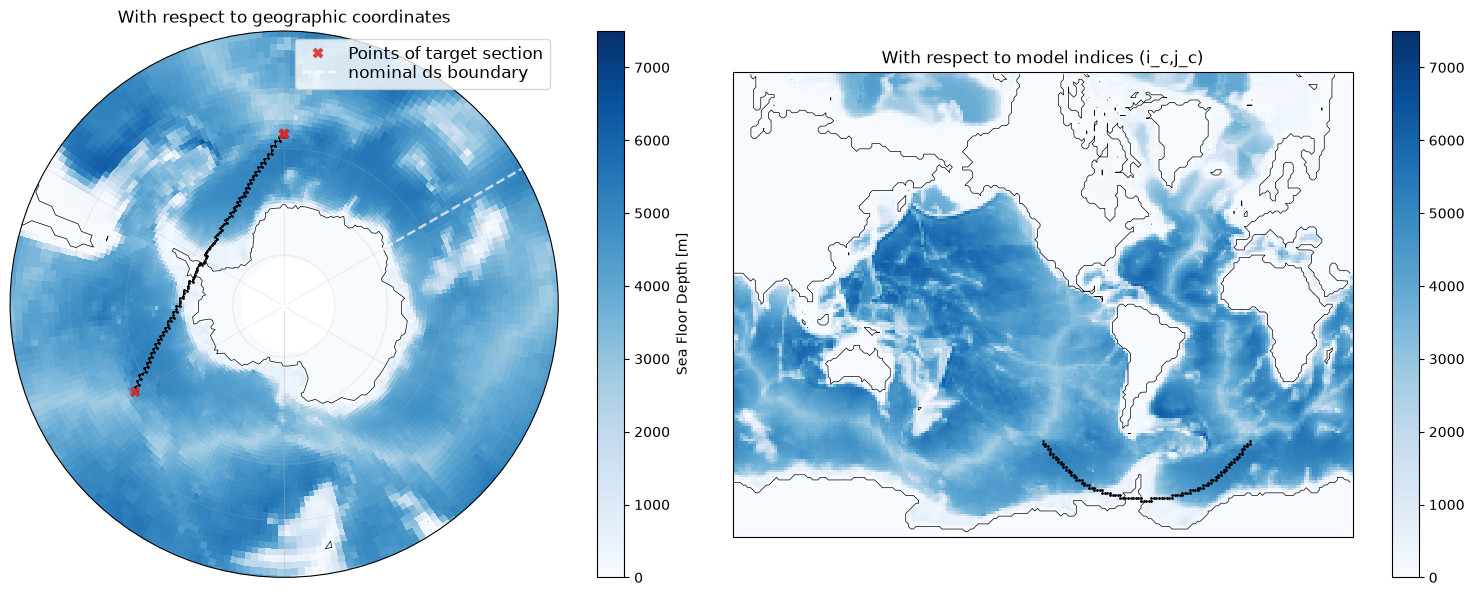

In [9]:
section_lons=[0, 240, 360]
section_lats=[lat]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

### Correct use: series of intermediate points less than 180º apart 

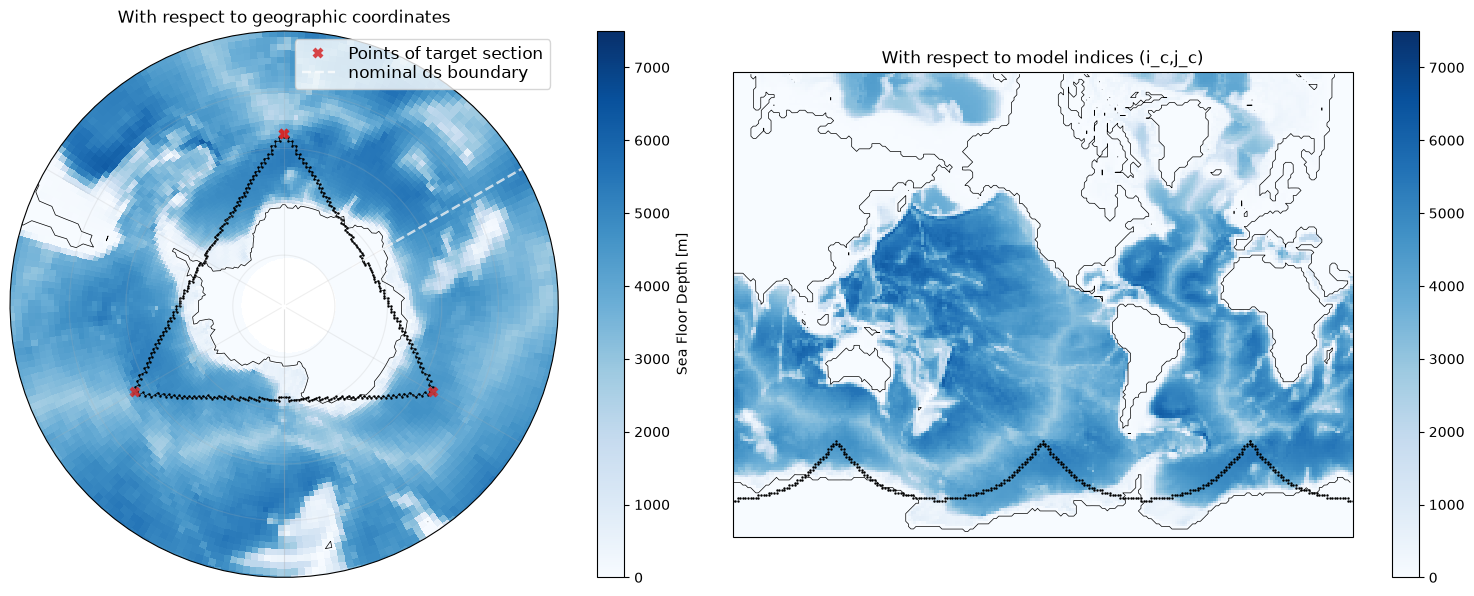

In [10]:
dlon=120
section_lons=np.arange(0., 360.+dlon, dlon)
section_lats=[lat]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)

plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

To make strictly zonal sections, simply stitch together many great circle arcs:

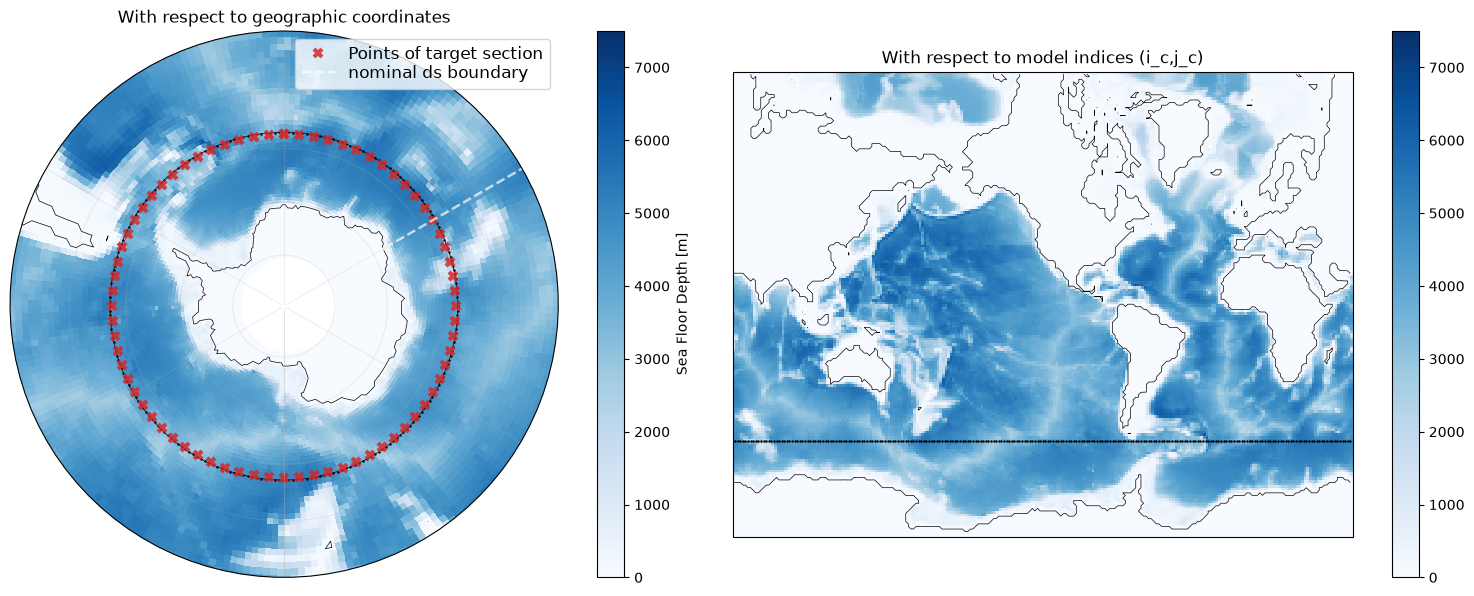

In [11]:
dlon=5
section_lons=np.arange(0., 360.+dlon, dlon)
section_lats=[lat]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

Or switch the keyword argument `curve` from its default of `great circle` to `latitude circle`:

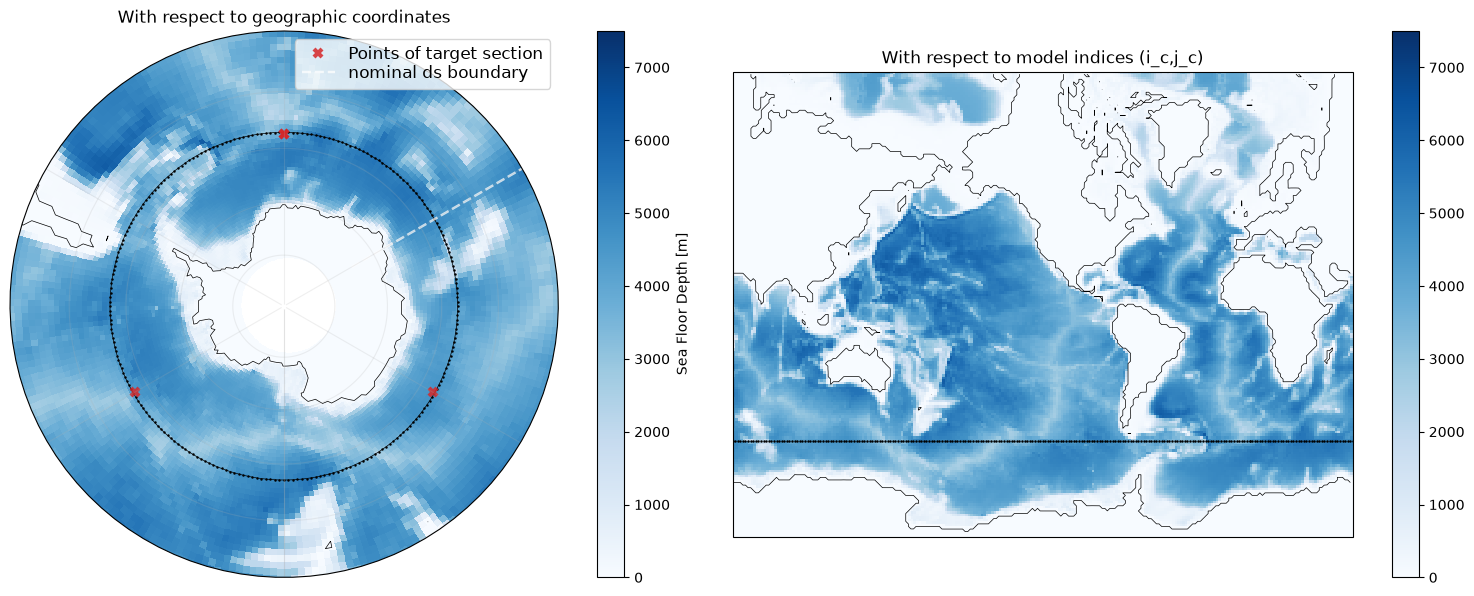

In [12]:
dlon=120
section_lons=np.arange(0., 360.+dlon, dlon)
section_lats=[lat]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
    curve="latitude circle"
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

## 3. Example of a complex section that crosses the boundary multiple times

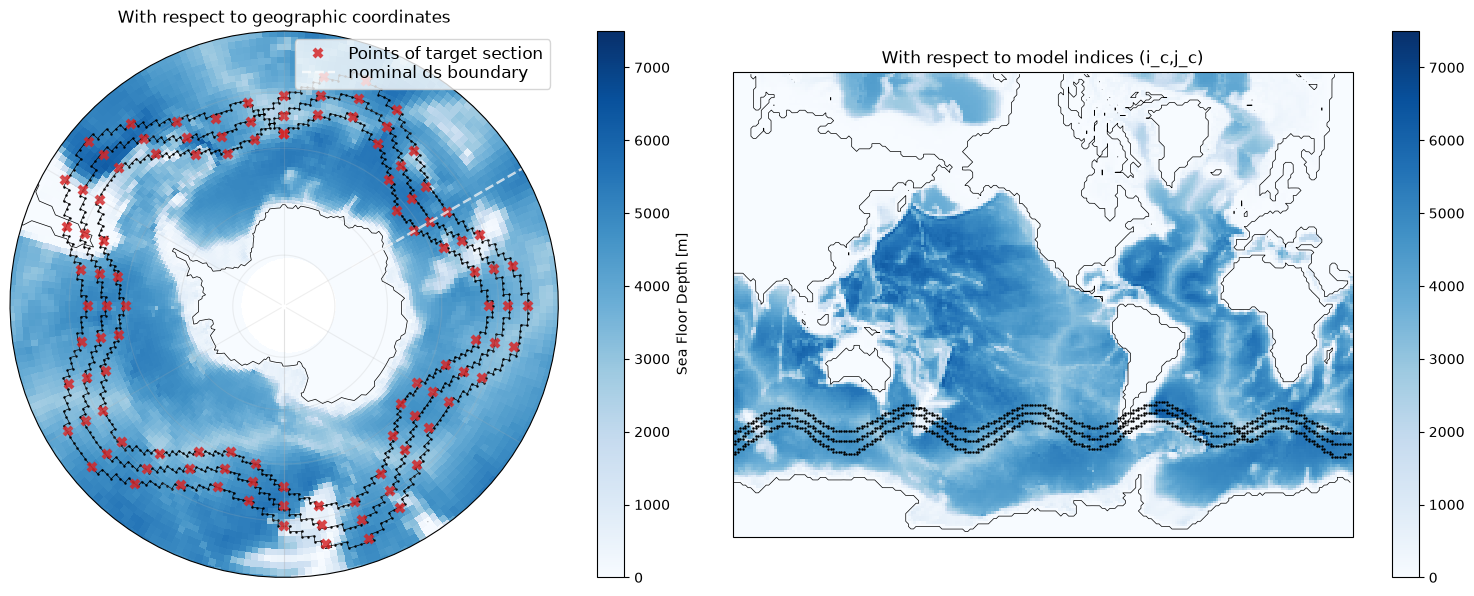

In [13]:
section_lons= np.arange(0, 360*3, 10.)
section_lats= lat + section_lons*(10/3.)/360. + 5*np.sin(5* (2*np.pi*section_lons/360.))

section_lons = np.append(section_lons, section_lons[0])
section_lats = np.append(section_lats, section_lats[0])

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.SouthPolarStereo());

## 4. Verify that sections work correctly near and across MOM6's tripolar grid seams

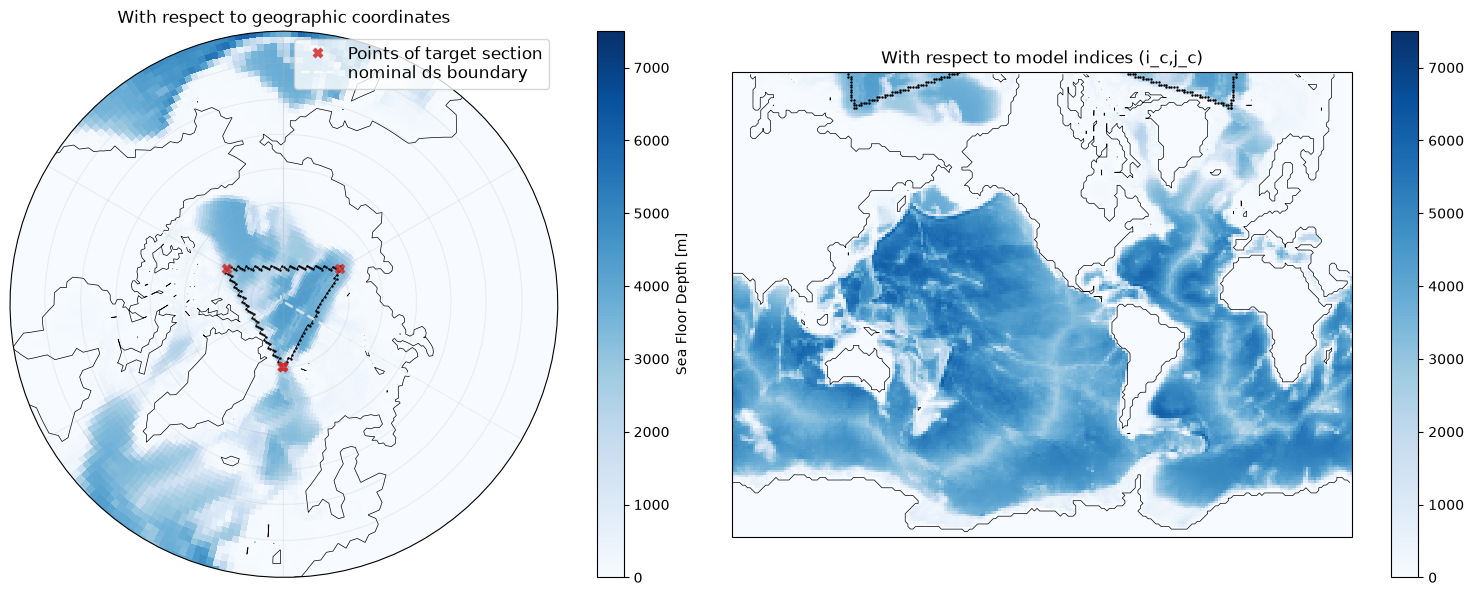

In [14]:
section_lons=[0, 120, 240, 360]
section_lats=[80]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.NorthPolarStereo());

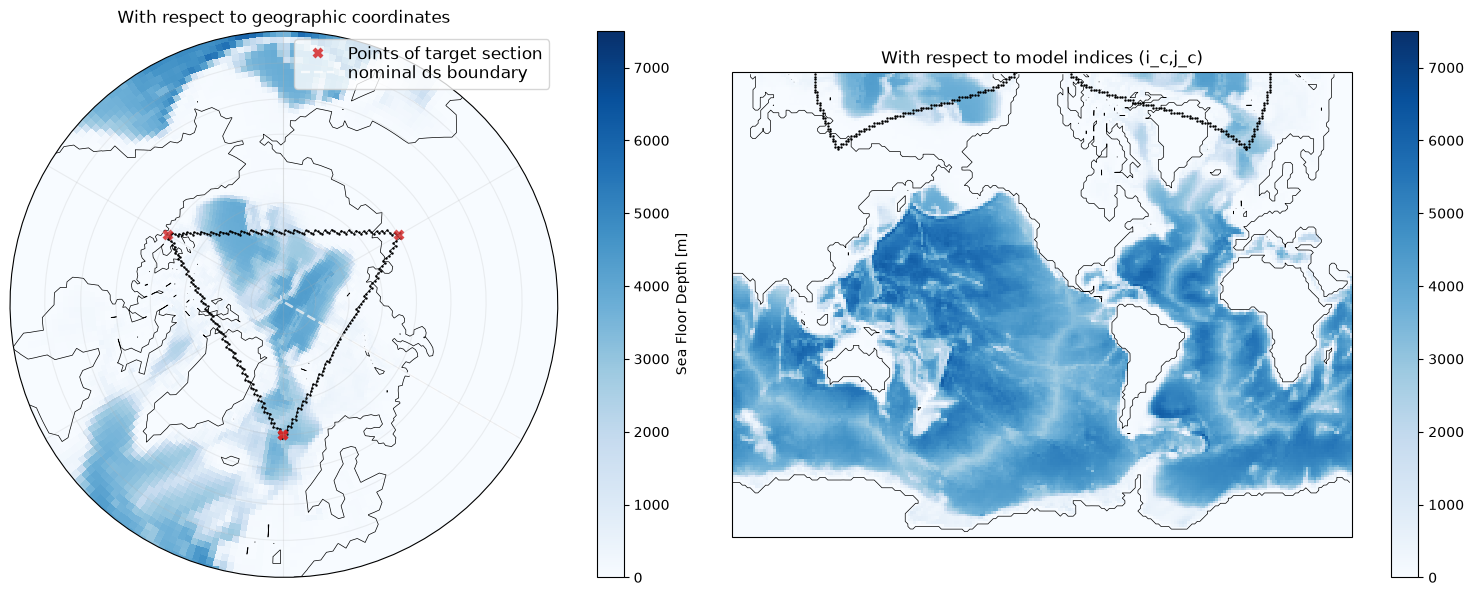

In [15]:
section_lons=[0, 120, 240, 360]
section_lats=[70]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.NorthPolarStereo());

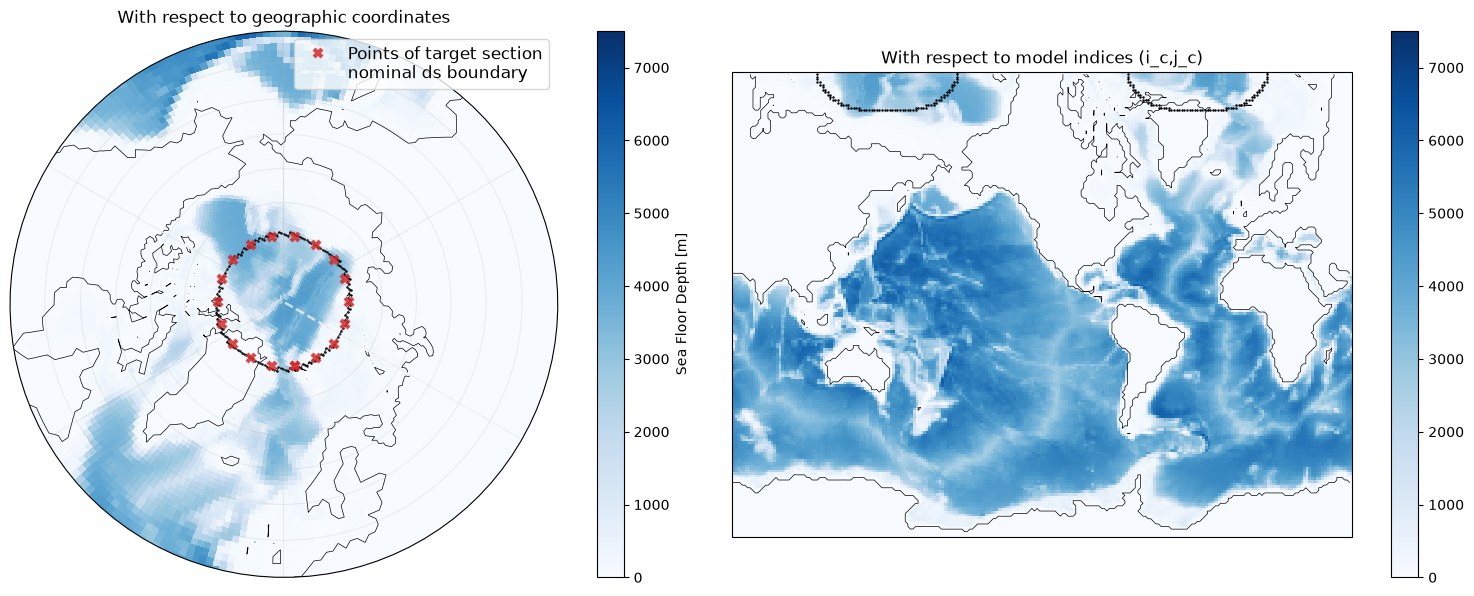

In [16]:
dlon = 20.
section_lons=np.arange(dlon/2, 360.+dlon, dlon)
section_lats=[80]*len(section_lons)

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.NorthPolarStereo());

Because the grid is loaded with its **bipolar north-fold** boundary (`padding={"X": "periodic", "Y": {"fold": "corner"}}`), sectionate traces sections that cross the tripolar seam directly — the topology-aware neighbor maps connect across the fold. (Earlier versions lacked native fold support and could stall on such paths, since the walker had to temporarily move away from the target to get across the seam; that is no longer the case.)

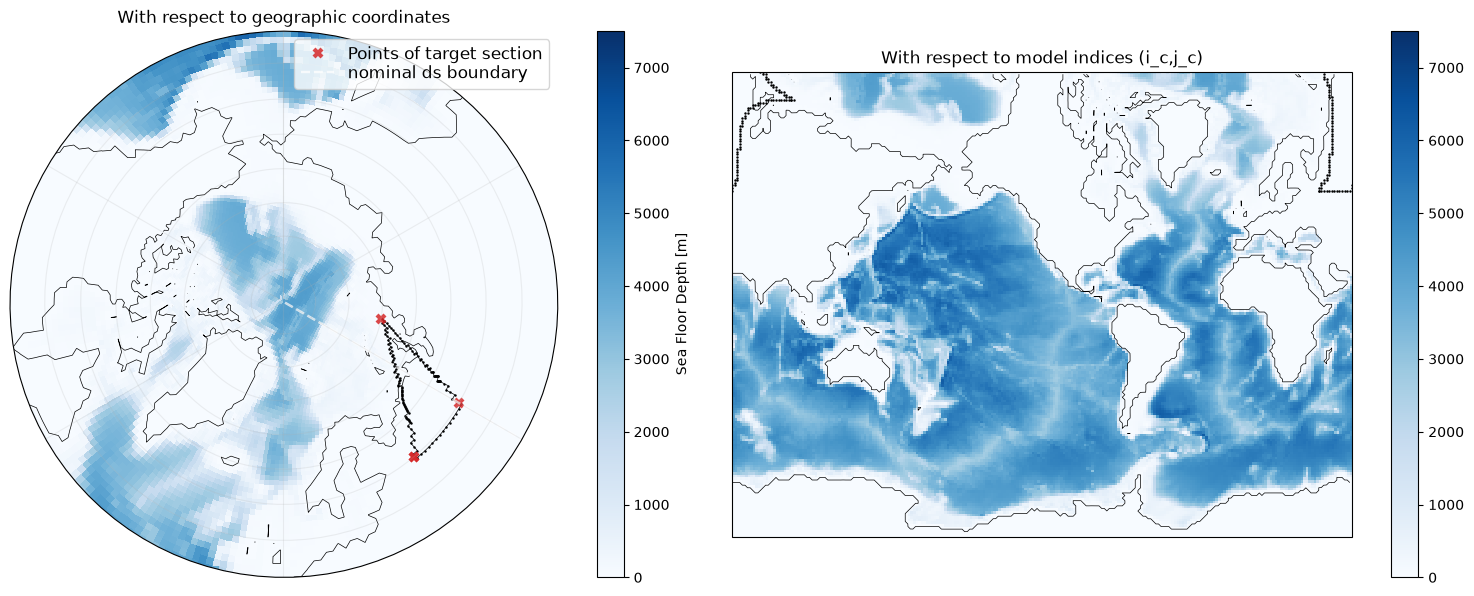

In [17]:
section_lons=[40, 60, 80., 40]
section_lats=[60, 60, 75, 60]

i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    section_lons,
    section_lats,
)
plot_sections(i_c, j_c, lons_c, lats_c, section_lons, section_lats, ds, projection=ccrs.NorthPolarStereo());